In [2]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [78]:
@dataclasses.dataclass
class Metrics:
    config: dict
    site_msds: np.ndarray
    separation_scores: np.ndarray
    separation_histories: np.ndarray

In [234]:
# config_ids = [9, 11, 12]
#config_ids = [15, 16]
#config_ids = [17, 18]
#config_ids = [20, 21]
#config_ids = [13, 14]
#config_ids = [12, 15, 13]
config_ids = [25, 26]

conds_metrics = {}

for config_id in config_ids:
    with open(f"config-{config_id}.json", "r") as file:
        config = json.load(file)

    with h5py.File(f"_outputs/metrics-{config_id}.h5", "r") as store:
        conds_metrics[config_id] = Metrics(
            config=config,
            site_msds=store["site_msds"][:],
            separation_scores=store["separation_scores"][:],
            separation_histories=store["separation_histories"][:],
        )

In [235]:
conds_colors = {
    7:  "r",  # AID
    8:  "k",  # NT, +cohsein
    9:  "r",  # AID
    10: "k",  # NT, +cohesin
    13: "r",  # AID
    14: "k",  # NT, +cohesin
    15: "r",  # AID
    16: "k",  # NT, +cohesin
    17: "r",  # AID
    18: "k",  # NT, +cohesin
    20: "r",  # AID
    21: "k",  # NT, +cohesin
    23: "k",  # NT, +cohesin
    24: "r",  # AID
    25: "r",  # AID
    26: "k",  # NT, +cohesin
}
#conds_colors = {
#    12: "k",
#    15: "gold",
#    13: "red",
#}

In [236]:
@dataclasses.dataclass
class MSDAnalysis:
    lags: np.ndarray
    means: np.ndarray
    stds: np.ndarray
    alpha: float
    beta: float

In [237]:
conds_msds = {}

for config_id, metrics in conds_metrics.items():
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    lags = np.arange(metrics.site_msds.shape[1]) * frame_interval
    msd_samples = einops.rearrange(metrics.site_msds, "r t s -> (r s) t")
    msd_mean = msd_samples.mean(axis=0)
    msd_std = msd_samples.std(axis=0)

    #x = np.tile(lags, msd_samples.shape[0])
    #y = msd_samples.flatten()
    #alpha, beta = fit_power_law(x, y)
    x = lags
    y = msd_mean
    alpha, beta = fit_power_law(x, y)

    conds_msds[config_id] = MSDAnalysis(
        lags=lags,
        means=msd_mean,
        stds=msd_std,
        alpha=alpha,
        beta=beta,
    )

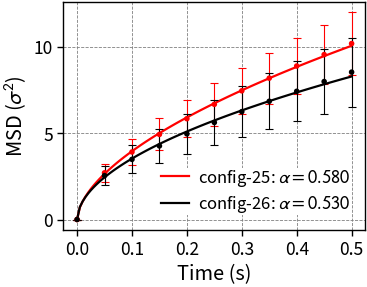

In [244]:
fig, ax = plt.subplots(figsize=(1.9, 1.5))

for config_id, msd in conds_msds.items():
    color = conds_colors.get(config_id)

    sample_thinning = 1
    x = msd.lags[::sample_thinning]
    y = msd.means[::sample_thinning]
    y_err = msd.stds[::sample_thinning]
    ax.errorbar(x, y, y_err, color=color, linewidth=0, elinewidth=0.4, capsize=1.3, capthick=0.4, zorder=2)
    ax.scatter(x, y, s=4, ec="none", fc=color, zorder=3)

    x = np.linspace(msd.lags[0], msd.lags[-1], num=100)
    y = x**msd.alpha * msd.beta
    s = f"config-{config_id}: " r"$ \alpha = %.3f $" % msd.alpha
    ax.plot(x, y, lw=0.8, color=color, label=s)

ax.grid(True, zorder=1)
ax.legend(frameon=True)
ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

pass

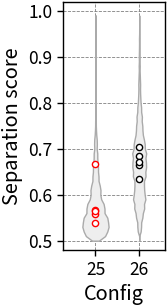

In [245]:
## score_bins = np.linspace(0.5, 1.6, num=51)
score_bins = np.linspace(0.5, 1.0, num=51)

fig, ax = plt.subplots(figsize=(0.9, 1.6))

for i, (config_id, metrics) in enumerate(conds_metrics.items()):
    color = conds_colors.get(config_id, "k")

    x = np.full_like(metrics.separation_scores, i)
    y = metrics.separation_scores
    ax.scatter(x, y, s=5, ec=color, fc="w", zorder=3)

    density_scale = 0.03

    density, _ = np.histogram(
        metrics.separation_histories.ravel(),
        bins=score_bins,
        density=True,
    )
    ax.fill_betweenx(
        score_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec="#aaa",
        fc="#eee",
        zorder=2,
    )

ax.margins(x=0.3)

ax.grid(True, zorder=1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(conds_metrics.keys())
ax.set_ylim(0.48, 1.62)
ax.set_ylim(0.48, 1.02)
ax.set_xlabel("Config")
ax.set_ylabel("Separation score")

pass

In [240]:
for config_id, metrics in conds_metrics.items():
    orders = np.argsort(metrics.separation_scores)
    median_instance = orders[len(orders) // 2]
    print(config_id, median_instance + 1)

25 3
26 4
